# Assignment 1

**Students names:** Marco Borghi, Arash Foroozanfar, Armina Sadeghi and Razieh Soleimanbeigi

**emails:** marco.borghi6@studio.unibo.it, arash.foroozanfar@studio.unibo.it, armina.sadeghi@studio.unibo.it, razieh.soleimanbeigi@studio.unibo.it



# [Task 1 - 1.0 points] Corpus

Use the following variable to define the path on Drive that contains the 3 json files, in the same format as described in the project specification:

The folder should contain  3 `.json` files representing `training`, `validation` and `test` sets.


In [ ]:
NLP_DATA_URL = '/content/drive/MyDrive/UNIVERSITA/NLP/A1/data'

Library imports

In [ ]:
!pip install gensim
!pip install transformers
!pip install datasets
!pip install accelerate -U
!pip install evaluate
!pip install bitsandbytes

In [ ]:
import sys
import shutil
import urllib
import tarfile
import json
import re
import os
import random
import itertools
from pathlib import Path
from collections import Counter
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from tqdm import tqdm

import nltk
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer, SnowballStemmer, PorterStemmer
from nltk.tokenize import word_tokenize, WhitespaceTokenizer
from nltk.corpus import wordnet, stopwords

import gensim
import gensim.downloader as gloader

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, GlobalMaxPooling1D, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

import torch
from torch.nn import CrossEntropyLoss, NLLLoss
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed
)
from datasets import Dataset

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected")

GPU detected: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r {NLP_DATA_URL} ./

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat '/content/drive/MyDrive/UNIVERSITA/NLP/A1/data': No such file or directory


In [ ]:
test_path = '/content/data/test.json'
train_path = '/content/data/training.json'
validation_path ='/content/data/validation.json'

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [ ]:
ID2LABEL = {0: '-', 1: 'DIRECT', 2: 'JUDGEMENTAL', 3: 'REPORTED'}
LABEL2ID = {'-': 0, 'DIRECT': 1, 'JUDGEMENTAL': 2, 'REPORTED': 3}

def process_json_file(file_path, label_mapping = LABEL2ID):
    """
    Given the file path, loads json file of the corresponding dataset and
    assign integer labels to each tweet based on majority voting.
    """

    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    df = pd.DataFrame.from_dict(data, orient='index')

    # if labels have the same number of votes, the tweet is removed from dataset to avoid ambiguos labelling.
    def get_majority_label(labels):
        label_counts = Counter(labels)
        max_count = max(label_counts.values())
        majority_labels = [label for label, count in label_counts.items() if count == max_count]

        if len(majority_labels) == 1:
            return majority_labels[0]
        else:
            return None

    df['label'] = df['labels_task2'].apply(get_majority_label)

    # Preserving data that are not null, are in english, and keeping four specified features: id_EXIST, lang, tweet, label
    df = df[df['label'].notna()]
    df = df[df['lang'] == 'en']
    df = df[['id_EXIST', 'lang', 'tweet', 'label']]

    df['label'] = df['label'].map(label_mapping)

    return df

train_df_raw = process_json_file(train_path)
validation_df_raw = process_json_file(validation_path)
test_df_raw = process_json_file(test_path)

# Printing dimensions and 5 rows of train, validation, and test datasets
print(f"Training dataframe shape: {train_df_raw.shape}")
print(f"Validation dataframe shape: {validation_df_raw.shape}")
print(f"Test dataframe shape: {test_df_raw.shape}")
print("\n")
print("Training dataframe samples: ")
display(train_df_raw.head())
print("\n")
print("Validation dataframe samples: ")
display(validation_df_raw.head())
print("\n")
print("Test dataframe samples: ")
display(test_df_raw.head())

Training dataframe shape: (2873, 4)
Validation dataframe shape: (150, 4)
Test dataframe shape: (280, 4)


Training dataframe samples: 


,id_EXIST,lang,tweet,label
200001,200001,en,FFS! How about laying the blame on the bastard...,0
200002,200002,en,Writing a uni essay in my local pub with a cof...,3
200003,200003,en,@UniversalORL it is 2021 not 1921. I dont appr...,3
200004,200004,en,@GMB this is unacceptable. Use her title as yo...,0
200005,200005,en,‘Making yourself a harder target’ basically bo...,0




Validation dataframe samples: 


,id_EXIST,lang,tweet,label
400001,400001,en,"@Mike_Fabricant “You should smile more, love. ...",0
400002,400002,en,@BBCWomansHour @LabWomenDec @EverydaySexism Sh...,3
400003,400003,en,#everydaysexism Some man moving my suitcase in...,3
400004,400004,en,@KolHue @OliverJia1014 lol gamergate the go to...,0
400005,400005,en,@ShelfStoriesGBL To me this has the same negat...,0




Test dataframe samples: 


,id_EXIST,lang,tweet,label
400178,400178,en,1st day at the pool on a beautiful Sunday in N...,0
400180,400180,en,"@KNasFanFic 🥺💖 same, though!!! the angst just ...",0
400181,400181,en,@themaxburns @GOP Fuck that cunt. Tried to vot...,1
400182,400182,en,@ultshunnie u gotta say some shit like “i’ll f...,1
400183,400183,en,"@FernsLewds “Mmm, fuck that cunt is hungry for...",1


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

In [ ]:
# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Download the missing POS tagger
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng')

# Download Open Multilingual Wordnet (needed for lemmatization)
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

# The roles a word has in a sentence (speech tags) can be in NLTK POS format or in wordnet format: this function convert them.
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def clean_tweet_data(df, text_column="tweet"):
    def clean_text(text):
        if not isinstance(text, str):
            print("problem")
            return ""

        # Convert to lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove mentions (e.g: @user)
        text = re.sub(r'@\w+', '', text)

        # Remove hashtags (e.g: #example)
        text = re.sub(r'#\w+', '', text)

        # Remove emojis and emoticons
        emoji_pattern = re.compile(
            "["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
            u"\U00002702-\U000027B0"
            u"\U000024C2-\U0001F251"
            "]+", flags=re.UNICODE
        )
        text = emoji_pattern.sub('', text)

        # Replace standalone numbers with <num>
        text = re.sub(r'\b\d+\b', '<num>', text)

        # Remove any word that includes '.com'
        text = re.sub(r'\b\w*\.com\w*\b', '', text)

        # For removing special characters we keep only letters, digits, whitespaces:
        text = re.sub(r'[^A-Za-z0-9\s]', '', text)

        # Remove specific quote characters (curly quotes)
        text = re.sub(r'[«»"“”„‟]', ' ', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        try:
            # POS tagging distinguishes the possible uses of a word (e.g: noun or verb) in order to perform a more precise lemmatization
            words = word_tokenize(text)
            pos_tags = pos_tag(words)
            lemmatized_words = []
            for word, tag in pos_tags:
                # To perform lemmatization we need each word and also the role it has on the sentence. This role can be expressed in the POS format or in the wordnet format (we need it in the wordnet format)
                wordnet_pos = get_wordnet_pos(tag)
                lemma = lemmatizer.lemmatize(word, wordnet_pos)
                lemmatized_words.append(lemma)
            text = ' '.join(lemmatized_words)
        except Exception as e:
            print(f"problem 2: lemmatization failed for text: '{text[:50]}...' - Error: {e}")
            # If tokenization fails, return the cleaned text without lemmatization
            pass

        return text

    df_clean = df.copy()
    df_clean[text_column] = df_clean[text_column].apply(clean_text)

    return df_clean

train_df = train_df_raw.copy()
validation_df = validation_df_raw.copy()
test_df = test_df_raw.copy()
train_df = clean_tweet_data(train_df)
validation_df = clean_tweet_data(validation_df)
test_df = clean_tweet_data(test_df)

print("\n")
print("Before cleaning:")
display(test_df_raw['tweet'].head())
print("\n")
print("After cleaning:")
display(test_df['tweet'].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!




Before cleaning:


,tweet
400178,1st day at the pool on a beautiful Sunday in N...
400180,"@KNasFanFic 🥺💖 same, though!!! the angst just ..."
400181,@themaxburns @GOP Fuck that cunt. Tried to vot...
400182,@ultshunnie u gotta say some shit like “i’ll f...
400183,"@FernsLewds “Mmm, fuck that cunt is hungry for..."




After cleaning:


,tweet
400178,1st day at the pool on a beautiful sunday in n...
400180,same though the angst just come and go lonely ...
400181,fuck that cunt try to vote her out multiple time
400182,u get ta say some shit like ill fuck that cunt...
400183,mmm fuck that cunt be hungry for this dick isn...


# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.


   * We load the Glove embedding: the vocabulary contains the union of tokens in train set and in GloVe
   * All the tokens in the **training** set that are not in GloVe  are added to the vocabulary, and the embedding is initialized with a random normal distribution
   * For the OOV tokens we assigned the special ``<UNK>`` token, that has the mean of all other embeddings as **static** embedding.
   * A padding token ``<PAD>``  is defined with a null vector as embedding
   * The embedding dimension is a paremeter (we tested models with different embedding dimensions).



In [ ]:
def load_glove_embedding(dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library
    """
    try:
        download_path = "glove-wiki-gigaword-{}".format(dimension)
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name or dimension.")
        raise e

    return emb_model

def build_vocabulary(train_df, embedding_dim=50):

    # Get all tokens from trainset and glove embedding
    trainset_tokens = [tweet.split() for tweet in train_df['tweet']]
    glove_embeddings = load_glove_embedding(dimension=embedding_dim)

    # Obtain set of unique tokens that is the union between the words in glove and those in the train set
    trainset_vocabulary = set([token for tweet in trainset_tokens for token in tweet])
    glove_vocabulary = set(glove_embeddings.key_to_index.keys())
    vocabulary = trainset_vocabulary.union(glove_vocabulary)

    # Special tokens for padding and for words out of vocabulary
    PAD_TOKEN = "[PAD]"
    OOV_TOKEN = "[UNK]"
    vocabulary = {PAD_TOKEN, OOV_TOKEN}.union(vocabulary)

    # We move the pad token to the front so that we can ignore zero during training (mask_zero = True)
    vocabulary = sorted(list(vocabulary))
    vocabulary.pop(vocabulary.index(PAD_TOKEN))
    vocabulary.insert(0, PAD_TOKEN)

    # Create mappings between indexes and words
    word_to_index = {}
    index_to_word = []

    for idx, word in enumerate(vocabulary):
        word_to_index[word] = idx
        index_to_word.append(word)

    # We initialize embeddings with a normal distribution for all words that are not present in the glove embedding
    np.random.seed(42)
    embeddings_matrix = np.random.normal(scale=0.01, size=(len(vocabulary), embedding_dim)).astype(np.float32)
    for word in vocabulary:
        if word in glove_embeddings:
            embeddings_matrix[word_to_index[word]] = glove_embeddings[word]

    # the embedding for the padding token is a null vector, while the embedding for out of vocabulary is the mean of other embeddings
    embeddings_matrix[word_to_index[PAD_TOKEN]] = np.zeros((embedding_dim,), dtype=np.float32)

    glove_indices = [word_to_index[w] for w in vocabulary if w in glove_embeddings]
    mean_embedding = np.mean(embeddings_matrix[glove_indices], axis=0)
    embeddings_matrix[word_to_index[OOV_TOKEN]] = mean_embedding

    print("Created vocabulary of size:", len(vocabulary))
    print("Padding Token has index ",word_to_index[PAD_TOKEN])
    print("Out of Vocabulary token has index ",word_to_index[OOV_TOKEN])

    return word_to_index, index_to_word, embeddings_matrix

def encode_text_into_indexes(tokens, word_to_index, max_length, oov_token="[UNK]", pad_token="[PAD]"):
    """
    Encodes a list of tokens into indices that will be used to get the corresponding embedding vector in the embedding matrix
    """
    encoded_text = []
    for token in tokens:
        if token in word_to_index:
            encoded_text.append(word_to_index[token])
        else:
            # OOV token not in vocabulary gets UNK
            encoded_text.append(word_to_index[oov_token])

    # We insert padding tokens in case the length of the tweet is inferior to max lenght allowed
    if len(encoded_text) < max_length:
        encoded_text = encoded_text + [word_to_index[pad_token]] * (max_length - len(encoded_text))
    else:
        encoded_text = encoded_text[:max_length]
    return encoded_text

def get_dataset_with_embeddings(train_df, validation_df, test_df, embedding_dim):
    """
    This function takes as input train, validation, and test dataframes along with embedding dim
    and returns as output train, validation, and test dataframes with encoded tweets along with embedding matrix
    """
    train_df = train_df.copy()
    validation_df = validation_df.copy()
    test_df = test_df.copy()
    word_to_index, index_to_word, embeddings_matrix = build_vocabulary(train_df, embedding_dim=embedding_dim)
    max_length = max([len(tweet.split()) for tweet in train_df['tweet']])
    print("Max length of tweets:", max_length)

    train_df['encoded'] = train_df['tweet'].apply(lambda x: encode_text_into_indexes(x.split(), word_to_index, max_length))
    validation_df['encoded'] = validation_df['tweet'].apply(lambda x: encode_text_into_indexes(x.split(), word_to_index, max_length))
    test_df['encoded'] = test_df['tweet'].apply(lambda x: encode_text_into_indexes(x.split(), word_to_index, max_length))

    return train_df, validation_df, test_df, embeddings_matrix, max_length, index_to_word

# [Task 4 - 1.0 points] Model definition

## 1. Architectures:

### **`Embedding` Layer**
* **Role:** Transforms integer-encoded words into dense vectors of fixed size.
* **Behavior:** Acts as a lookup table. If `trainable=True`, these vectors update during backpropagation to learn domain-specific nuances.

### **`Bidirectional(LSTM)` Layer**
* **Role:** Processes the input sequence in two directions: forward (start to end) and backward (end to start).
* **Output:** By default, Keras concatenates the hidden states from both directions.
* **Configuration in Baseline vs. Stacked:**
    * **Baseline Model:** Uses `return_sequences=False`. It returns only the final hidden state (suitable for our classification task).
    * **Stacked Model (Layer 1):** Uses `return_sequences=True`. It outputs the full sequence of hidden states (one vector per time step) to feed into the next LSTM layer.
    * **Stacked Model (Layer 2):** Uses `return_sequences=False`. It consumes the sequence from the first layer and outputs the final hidden state for classification.

### **`Dense` Layer (Output)**
* **Role:** Maps the high-level features extracted by the LSTM to the final class probabilities.
* **Configuration:**
    * **Units:** `4` (The number of target classes).
    * **Activation:** `'softmax'` (Converts the output into a probability distribution summing to 1).


## 2. Parameter Definitions
These parameters control the behavior of both the `baseline_lstm_model` and the `stacked_layers_lstm_model`.

* **`vocabulary_size`** (`input_dim` in Embedding)
    * Defines the total number of unique words in the vocabulary.
    * *Note:* It is not the dimension of the input vector, but rather the range of integer indices the model expects.

* **`embedding_dimension`** (`output_dim` in Embedding)
    * The size of the dense vector representation for each word.
    * For every sample, the embedding layer outputs `[input_length]` vectors, each of this dimension.

* **`embeddings`** (`weights` in Embedding)
    * The matrix containing the pre-trained word vectors (GloVe) used to initialize the layer.

* **`lenght_of_input_sequence`** (`input_length` in Embedding)
    * The fixed length of the input sequences.
    * Text is padded or truncated to match this length so that tensor shapes are consistent.

* **`mask_zero`** (set to `True`)
    * Tells the model to strictly ignore padding values (zeros) during calculations, ensuring padding doesn't skew the results.

* **`allow_embedding_training`** (`trainable` in Embedding)
    * **`False`**: Keeps pre-trained embeddings fixed. This is faster and reduces overfitting.
    * **`True`**: Allows fine-tuning of embeddings. This is useful if your specific domain requires different word relationships than general language.

* **`lstm_dimension`** (`units` in LSTM)
    * Defines the size of the hidden states **and** the size of the memory cell vector within the LSTM unit.
    * Because the layer is `Bidirectional`, the actual output dimension will be `units * 2` (concatenation of forward and backward states).

* **`dropout_rate`**
    * Randomly shuts down connections from the **new input** to the gate computations to prevent overfitting.

* **`recurrent_dropout_rate`**
    * Randomly shuts down connections from the **previous hidden state** to the gate computations.
    * *Note:* Recurrent dropout affects the hidden state, but not the memory cell.


In [ ]:
def baseline_lstm_model(embeddings, embedding_dimension, allow_embedding_training, vocabulary_size, lstm_dimension, lenght_of_input_sequence , dropout_rate=0.3, recurrent_dropout_rate=0.3):

    model = Sequential(name='Baseline_BiLSTM_Model')

    model.add(Embedding(input_dim=vocabulary_size, output_dim=embedding_dimension,weights=[embeddings], input_length=lenght_of_input_sequence,mask_zero=True, trainable=allow_embedding_training,name='encoder_embedding'))

    model.add(Bidirectional(LSTM(units=lstm_dimension, return_sequences=False, dropout=dropout_rate, recurrent_dropout=recurrent_dropout_rate),name='bidirectional_lstm'))

    model.add(Dense(4, activation='softmax', name='output_layer'))

    return model

def stacked_layers_lstm_model(embeddings, embedding_dimension, allow_embedding_training, vocabulary_size, lstm_dimension, lenght_of_input_sequence, dropout_rate=0.3, recurrent_dropout_rate=0.3):

    model = Sequential(name='Baseline_BiLSTM_Model')

    model.add(Embedding(input_dim=vocabulary_size, output_dim=embedding_dimension,weights=[embeddings],input_length=lenght_of_input_sequence,mask_zero=True,trainable=allow_embedding_training,name='encoder_embedding'))

    model.add(Bidirectional(LSTM(units=lstm_dimension, return_sequences=True, dropout=dropout_rate,recurrent_dropout=recurrent_dropout_rate), name='bidirectional_lstm'))

    model.add(Bidirectional(LSTM(units=lstm_dimension, return_sequences=False, dropout=dropout_rate, recurrent_dropout=recurrent_dropout_rate), name='bidirectional_lstm_2'))

    model.add(Dense(4, activation='softmax', name='output_layer'))

    return model


# [Task 5 - 1.0 points] Training and Evaluation


### Instructions

* Pick **at least** three seeds for robust estimation. ( we picked 3)
* Train **all** models on the train set.
* Evaluate **all** models on the validation and test sets.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric. (reported in the table below).
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).
<br>

Once the best hyperparameters configuration has been obtained, only the model of the seed with best macro F1 score is used for evaluation on the test set: this is an arbitrary choice that we have made, in order to perform the evaluation on the test set with only one model for each architecture.

In [ ]:
def create_batches(df, batch_size=32, shuffle=True):
    """
    Creates a tf.data.Dataset from a pandas dataframe.
    In the result analysis we need to iterate more than once over the batches, so we do not shuffle by default.
    """
    labels = df['label'].values
    inputs = np.stack(df['encoded'].values, axis=0)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, labels))
    if shuffle:
        dataset = dataset.shuffle(len(inputs))

    batches = dataset.batch(batch_size)
    return batches

def set_seeds(seed):
    """
    Sets all seeds for reproducibility and enables deterministic operations.
    """
    K.clear_session()

    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # 1. Force TensorFlow to use deterministic CuDNN algorithms
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    # 2. Force TensorFlow to use deterministic GPU implementations
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

def compute_metrics(model, batches):
    """
    Given a model, compute macro-F1, precision, and recall for each class
    """
    y_true = []
    y_pred = []
    for X_batch, y_batch in batches:
        predictions = model.predict(X_batch, verbose=0)
        # We use argmax to get class with highest probability
        predicted_labels = np.argmax(predictions, axis=1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(predicted_labels)

    # Compute macro-F1 (average of F1 for each class)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Compute precision and recall for each class
    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)

    return f1_macro, precision_per_class, recall_per_class

The function below assigns higher importance to underrepresented classes based on frequency, helping the model learn effectively from imbalanced training data.

In [ ]:
def calculate_class_weights(train_df):
    """
    Calculate class weights from training data
    Uses the formula: weight_j = total_samples / (n_classes * n_samples_j)
    """
    # Get label distribution from your train_df
    label_counts = train_df['label'].value_counts().sort_index()
    total_samples = len(train_df)
    n_classes = len(label_counts)

    class_weights = {}
    for class_idx, count in label_counts.items():
        class_weights[class_idx] = total_samples / (n_classes * count)

    return class_weights

The following callback is used for learning curves

In [ ]:
class F1ScoreCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset):
        super().__init__()
        self.val_dataset = val_dataset

    def on_epoch_end(self, epoch, logs=None):
        # We reuse your existing compute_metrics function
        val_f1, _, _ = compute_metrics(self.model, self.val_dataset)
        logs['val_f1'] = val_f1

`train_model` performs a grid search over hyperparameters, training models with multiple random seeds and selecting the configuration achieving the highest average F1 score on the validation set.

In [ ]:
def train_model(train_df_clean, validation_df_clean, test_df_clean, hyperparameters = {}, model_type = 'baseline'):
    """
    We train a model on the train set and evaluate it on the validation set, using 3 different seeds.
    At the end the hyperparameters configuration that resulted in the best model are returned.
    Between the 3 models (each for one seed) with the best average F1 score, the one with highest F1 score is selected for result analysis
    """

    BEST_F1_SCORE, BEST_PARAMS, BEST_MODEL, BEST_PRECISIONS, BEST_RECALLS, BEST_F1_PER_CLASS, BEST_STD_PRECISIONS, BEST_STD_RECALLS, BEST_STD_F1, BEST_HISTORY = -np.inf, None, None, None, None, None, None, None, None, None

    for embedding_dimension in hyperparameters['embedding_dimension']:

        param_combinations = itertools.product(
            hyperparameters['lstm_units'],
            hyperparameters['lr'],
            hyperparameters['trainable_emb'],
            hyperparameters['epochs'],
            hyperparameters['batch_size'],
            hyperparameters['dropout_rate'],
            hyperparameters['recurrent_dropout_rate'],
            hyperparameters['class_weight_strategy']
        )

        train_df, validation_df, test_df , embeddings_matrix, max_length, _ = get_dataset_with_embeddings(train_df_clean, validation_df_clean, test_df_clean, embedding_dimension)
        vocab_size = embeddings_matrix.shape[0]

        # we consider all possible combinations of  hyperparameters.
        for lstm_unit, lr, trainable_emb, epochs, batch_size, dropout_rate, recurrent_dropout_rate, class_weight_strategy in param_combinations:

            seeds = [42, 150, 300]
            all_val_f1s = []
            all_val_precisions = []
            all_val_recalls = []
            current_models = []

            # an hyperparameter is relative to giving different weight to the classes during training
            if class_weight_strategy:
              class_weights = calculate_class_weights(train_df_clean)
              print("class_weights: ", class_weights)
            else:
              class_weights = None

            for seed in seeds:
                set_seeds(seed)

                if model_type == 'baseline':
                    model = baseline_lstm_model(
                        embeddings=embeddings_matrix,
                        embedding_dimension=embedding_dimension,
                        allow_embedding_training=trainable_emb,
                        vocabulary_size=vocab_size,
                        lstm_dimension=lstm_unit,
                        lenght_of_input_sequence = max_length,
                        dropout_rate=dropout_rate,
                        recurrent_dropout_rate=recurrent_dropout_rate
                    )
                else: # we get inside this branch only for the stacked model
                     model = stacked_layers_lstm_model(
                        embeddings=embeddings_matrix,
                        embedding_dimension=embedding_dimension,
                        allow_embedding_training=trainable_emb,
                        vocabulary_size=vocab_size,
                        lstm_dimension=lstm_unit,
                        lenght_of_input_sequence = max_length,
                        dropout_rate=dropout_rate,
                        recurrent_dropout_rate=recurrent_dropout_rate
                    )

                model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=lr),metrics=['accuracy'])

                train_dataset = create_batches(train_df, batch_size=batch_size)
                val_dataset = create_batches(validation_df, batch_size=batch_size)
                val_dataset_for_callback = create_batches(validation_df, batch_size=batch_size, shuffle=False)

                current_models.append(model)

                history = model.fit(train_dataset, epochs=epochs, validation_data=val_dataset, verbose=1, class_weight=class_weights, callbacks = [F1ScoreCallback(val_dataset_for_callback)])

                val_f1_model_baseline, val_precisions, val_recalls = compute_metrics(model, val_dataset)
                all_val_f1s.append(val_f1_model_baseline)
                all_val_precisions.append(val_precisions)
                all_val_recalls.append(val_recalls)

            # Calculate mean and standard deviation for all metrics
            val_f1_mean = np.mean(all_val_f1s)
            val_f1_std = np.std(all_val_f1s)
            avg_precisions = np.mean(all_val_precisions, axis=0)
            val_precision_std = np.std(all_val_precisions, axis=0)
            avg_recalls = np.mean(all_val_recalls, axis=0)
            val_recall_std = np.std(all_val_recalls, axis=0)
            avg_f1_per_class = 2 * (avg_precisions * avg_recalls) / (avg_precisions + avg_recalls + 1e-8)

            print(f"MODEL {model_type}: F1 mean -> {val_f1_mean:.4f}, F1 std ->{val_f1_std:.4f} \n")
            print("-"*30)

            if val_f1_mean > BEST_F1_SCORE:

                BEST_PARAMS = {
                    'lstm_units': lstm_unit,
                    'trainable_emb': trainable_emb,
                    'epochs': epochs,
                    'batch_size': batch_size,
                    'lr': lr,
                    'dropout_rate': dropout_rate,
                    'recurrent_dropout_rate': recurrent_dropout_rate,
                    "embedding_dimension": embedding_dimension
                }

                # for result evaluation we pick the model with best F1 score, among the 3 models of the 3 seeds
                BEST_MODEL = current_models[np.argmax(all_val_f1s)]
                BEST_F1_SCORE = val_f1_mean
                BEST_PRECISIONS = avg_precisions
                BEST_RECALLS = avg_recalls
                BEST_STD_PRECISIONS = val_precision_std
                BEST_STD_RECALLS = val_recall_std
                BEST_STD_F1 = val_f1_std
                BEST_F1_PER_CLASS = avg_f1_per_class
                BEST_HISTORY = history

    return BEST_PARAMS, BEST_MODEL, BEST_F1_SCORE, BEST_PRECISIONS, BEST_RECALLS, BEST_F1_PER_CLASS, BEST_STD_PRECISIONS, BEST_STD_RECALLS, BEST_STD_F1, BEST_HISTORY


**BASELINE MODEL training**

To speed up execution, the code only keeps the hyperparameters that produced the highest average F1-score across the 3 seeds. The hyperparameter ranges actually tested for the baseline model are the following:

```
hyperparameters = {
    'embedding_dimension': [50, 100],
    'lstm_units':  [64,128],
    'lr': [1e-3, 1e-2],
    'trainable_emb': [False, True],
    'epochs': [16],
    'batch_size': [32,64],
    'dropout_rate': [0.33],
    'recurrent_dropout_rate': [0.33],
    'class_weight_strategy': [False]
}

hyperparameters = {
    'embedding_dimension': [50, 100],
    'lstm_units':  [128],
    'lr': [1e-2],
    'trainable_emb': [True],
    'epochs': [32],
    'batch_size': [32,64],
    'dropout_rate': [0.33],
    'recurrent_dropout_rate': [0.33],
    'class_weight_strategy': [False]
}
```


In [ ]:
m1_hyperparameters = {
    'embedding_dimension': [50],
    'lstm_units': [128],
    'lr': [0.01],
    'trainable_emb': [True],
    'epochs': [16],
    'batch_size': [32],
    'dropout_rate': [0.33],
    'recurrent_dropout_rate': [0.33],
    'class_weight_strategy': [False]
}

m1_hyperparams, m1_best_model, m1_scores, m1_precisions, m1_recalls, m1_f1_per_class, m1_std_precision, m1_std_recall, m1_std_f1, m1_history  = train_model(train_df, validation_df, test_df, m1_hyperparameters, 'baseline')

Created vocabulary of size: 401822
Padding Token has index  0
Out of Vocabulary token has index  43001
Max length of tweets: 62


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 80s 703ms/step - accuracy: 0.6434 - loss: 1.0055 - val_accuracy: 0.6933 - val_loss: 0.8515 - val_f1: 0.2920
Epoch 2/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 67s 543ms/step - accuracy: 0.7629 - loss: 0.6761 - val_accuracy: 0.7333 - val_loss: 0.7434 - val_f1: 0.4323
Epoch 3/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 76s 474ms/step - accuracy: 0.8675 - loss: 0.3720 - val_accuracy: 0.7600 - val_loss: 0.8615 - val_f1: 0.4394
Epoch 4/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 83s 484ms/step - accuracy: 0.9295 - loss: 0.1875 - val_accuracy: 0.7333 - val_loss: 1.0812 - val_f1: 0.4770
Epoch 5/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 476ms/step - accuracy: 0.9753 - loss: 0.0742 - val_accuracy: 0.7200 - val_loss: 1.2869 - val_f1: 0.3377
Epoch 6/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 479ms/step - accuracy: 0.9814 - loss: 0.0485 - val_accuracy: 0.7267 - val_loss: 1.4089 - val_f1: 0.4240
Epoch 7/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 479ms/step - accuracy: 0.9906 - loss: 0.0331 - val_accuracy: 0.7600 - val_loss: 1.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


90/90 ━━━━━━━━━━━━━━━━━━━━ 53s 506ms/step - accuracy: 0.6757 - loss: 0.9505 - val_accuracy: 0.7000 - val_loss: 0.8355 - val_f1: 0.3157
Epoch 2/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 481ms/step - accuracy: 0.7725 - loss: 0.6703 - val_accuracy: 0.7467 - val_loss: 0.7526 - val_f1: 0.3754
Epoch 3/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 492ms/step - accuracy: 0.8699 - loss: 0.3849 - val_accuracy: 0.7400 - val_loss: 1.0279 - val_f1: 0.3479
Epoch 4/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 481ms/step - accuracy: 0.9258 - loss: 0.2023 - val_accuracy: 0.6533 - val_loss: 1.2173 - val_f1: 0.3924
Epoch 5/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 486ms/step - accuracy: 0.9701 - loss: 0.0896 - val_accuracy: 0.6867 - val_loss: 1.4416 - val_f1: 0.4746
Epoch 6/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 484ms/step - accuracy: 0.9827 - loss: 0.0583 - val_accuracy: 0.6800 - val_loss: 1.6163 - val_f1: 0.3671
Epoch 7/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 484ms/step - accuracy: 0.9881 - loss: 0.0331 - val_accuracy: 0.7133 - val_loss: 1.7413 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


90/90 ━━━━━━━━━━━━━━━━━━━━ 53s 517ms/step - accuracy: 0.6604 - loss: 0.9864 - val_accuracy: 0.7067 - val_loss: 0.8582 - val_f1: 0.2275
Epoch 2/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 483ms/step - accuracy: 0.7652 - loss: 0.6751 - val_accuracy: 0.7333 - val_loss: 0.7617 - val_f1: 0.3937
Epoch 3/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 486ms/step - accuracy: 0.8548 - loss: 0.4004 - val_accuracy: 0.7467 - val_loss: 0.8431 - val_f1: 0.4712
Epoch 4/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 492ms/step - accuracy: 0.9256 - loss: 0.2056 - val_accuracy: 0.7467 - val_loss: 1.1070 - val_f1: 0.3919
Epoch 5/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 490ms/step - accuracy: 0.9599 - loss: 0.1081 - val_accuracy: 0.6733 - val_loss: 1.2863 - val_f1: 0.3898
Epoch 6/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 81s 479ms/step - accuracy: 0.9864 - loss: 0.0500 - val_accuracy: 0.6867 - val_loss: 1.2902 - val_f1: 0.4297
Epoch 7/16
90/90 ━━━━━━━━━━━━━━━━━━━━ 83s 491ms/step - accuracy: 0.9921 - loss: 0.0307 - val_accuracy: 0.7333 - val_loss: 1.5122 - val_

**STACKED MODEL training**


To speed up execution, the code only keeps the hyperparameters that produced the highest average F1-score across the 3 seeds. The hyperparameter range actually tested for the stacked model is the following:

```
hyperparameters = {
    'embedding_dimension': [50, 100],
    'lstm_units':  [128, 256],
    'lr': [1e-3, 1e-2],
    'trainable_emb': [True],
    'epochs': [16],
    'batch_size': [32, 64],
    'dropout_rate': [0.33],
    'recurrent_dropout_rate': [0.33],
    'class_weight_strategy': [False, True]
}

```


In [ ]:
m2_hyperparameters = {
    'embedding_dimension': [100],
    'lstm_units': [128],
    'lr': [0.001],
    'trainable_emb': [True],
    'epochs': [16],
    'batch_size': [64],
    'dropout_rate': [0.33],
    'recurrent_dropout_rate': [0.33],
    'class_weight_strategy': [False]
}

m2_hyperparams, m2_best_model, m2_scores, m2_precisions, m2_recalls, m2_f1_per_class, m2_std_precision, m2_std_recall, m2_std_f1, m2_history  = train_model(train_df, validation_df, test_df, m2_hyperparameters, 'stacked')

[==================================================] 100.0% 128.1/128.1MB downloaded
Created vocabulary of size: 401822
Padding Token has index  0
Out of Vocabulary token has index  43001
Max length of tweets: 62


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6358 - loss: 0.9915 - val_accuracy: 0.7000 - val_loss: 0.8973 - val_f1: 0.2255
Epoch 2/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 982ms/step - accuracy: 0.6989 - loss: 0.8488 - val_accuracy: 0.7267 - val_loss: 0.8085 - val_f1: 0.2771
Epoch 3/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.7440 - loss: 0.7311 - val_accuracy: 0.7333 - val_loss: 0.7878 - val_f1: 0.3352
Epoch 4/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 975ms/step - accuracy: 0.7405 - loss: 0.7059 - val_accuracy: 0.7600 - val_loss: 0.7310 - val_f1: 0.4176
Epoch 5/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 980ms/step - accuracy: 0.7648 - loss: 0.6312 - val_accuracy: 0.7467 - val_loss: 0.7479 - val_f1: 0.4027
Epoch 6/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.7873 - loss: 0.5854 - val_accuracy: 0.7533 - val_loss: 0.7335 - val_f1: 0.4243
Epoch 7/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 979ms/step - accuracy: 0.8340 - loss: 0.4832 - val_accuracy: 0.7733 - val_loss: 0.7715 - va

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6546 - loss: 0.9774 - val_accuracy: 0.6867 - val_loss: 0.8852 - val_f1: 0.2691
Epoch 2/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6967 - loss: 0.8360 - val_accuracy: 0.7200 - val_loss: 0.8229 - val_f1: 0.2941
Epoch 3/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 965ms/step - accuracy: 0.7122 - loss: 0.7776 - val_accuracy: 0.7200 - val_loss: 0.8102 - val_f1: 0.3136
Epoch 4/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 962ms/step - accuracy: 0.7370 - loss: 0.7259 - val_accuracy: 0.7200 - val_loss: 0.7611 - val_f1: 0.3894
Epoch 5/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 45s 994ms/step - accuracy: 0.7718 - loss: 0.6325 - val_accuracy: 0.7333 - val_loss: 0.7713 - val_f1: 0.4442
Epoch 6/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 81s 967ms/step - accuracy: 0.7812 - loss: 0.5930 - val_accuracy: 0.7400 - val_loss: 0.7874 - val_f1: 0.4341
Epoch 7/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 960ms/step - accuracy: 0.8078 - loss: 0.5239 - val_accuracy: 0.7333 - val_loss: 0.7988 -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6535 - loss: 0.9866 - val_accuracy: 0.7000 - val_loss: 0.9166 - val_f1: 0.2059
Epoch 2/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 76s 957ms/step - accuracy: 0.6993 - loss: 0.8447 - val_accuracy: 0.7267 - val_loss: 0.8172 - val_f1: 0.2866
Epoch 3/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 955ms/step - accuracy: 0.7034 - loss: 0.7661 - val_accuracy: 0.7400 - val_loss: 0.8037 - val_f1: 0.3653
Epoch 4/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 43s 956ms/step - accuracy: 0.7412 - loss: 0.6998 - val_accuracy: 0.7267 - val_loss: 0.7417 - val_f1: 0.4081
Epoch 5/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 974ms/step - accuracy: 0.7404 - loss: 0.6640 - val_accuracy: 0.7200 - val_loss: 0.7399 - val_f1: 0.4037
Epoch 6/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 80s 952ms/step - accuracy: 0.7952 - loss: 0.5579 - val_accuracy: 0.7333 - val_loss: 0.7852 - val_f1: 0.3994
Epoch 7/16
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 953ms/step - accuracy: 0.7994 - loss: 0.5400 - val_accuracy: 0.7400 - val_loss: 0.762

In [ ]:
model_names = ["Baseline", "Stacked"]

models_data = [
    {
        "model": model_names[0],
        "macro f1": f"{m1_scores:.4f} (± {m1_std_f1:.4f})",
        "class 0 recall": f"{m1_recalls[0]:.4f} (± {m1_std_recall[0]:.4f})",
        "class 1 recall": f"{m1_recalls[1]:.4f} (± {m1_std_recall[1]:.4f})",
        "class 2 recall": f"{m1_recalls[2]:.4f} (± {m1_std_recall[2]:.4f})",
        "class 3 recall": f"{m1_recalls[3]:.4f} (± {m1_std_recall[3]:.4f})",
        "class 0 precision": f"{m1_precisions[0]:.4f} (± {m1_std_precision[0]:.4f})",
        "class 1 precision": f"{m1_precisions[1]:.4f} (± {m1_std_precision[1]:.4f})",
        "class 2 precision": f"{m1_precisions[2]:.4f} (± {m1_std_precision[2]:.4f})",
        "class 3 precision": f"{m1_precisions[3]:.4f} (± {m1_std_precision[3]:.4f})",
        "trainable emb": m1_hyperparams["trainable_emb"],
        "batch size": m1_hyperparams["batch_size"],
        "lstm units": m1_hyperparams["lstm_units"],
        "embedding dimension": m1_hyperparams["embedding_dimension"],
        "learning rate": m1_hyperparams["lr"],
    },
    {
        "model": model_names[1],
        "macro f1": f"{m2_scores:.4f} (± {m2_std_f1:.4f})",
        "class 0 recall": f"{m2_recalls[0]:.4f} (± {m2_std_recall[0]:.4f})",
        "class 1 recall": f"{m2_recalls[1]:.4f} (± {m2_std_recall[1]:.4f})",
        "class 2 recall": f"{m2_recalls[2]:.4f} (± {m2_std_recall[2]:.4f})",
        "class 3 recall": f"{m2_recalls[3]:.4f} (± {m2_std_recall[3]:.4f})",
        "class 0 precision": f"{m2_precisions[0]:.4f} (± {m2_std_precision[0]:.4f})",
        "class 1 precision": f"{m2_precisions[1]:.4f} (± {m2_std_precision[1]:.4f})",
        "class 2 precision": f"{m2_precisions[2]:.4f} (± {m2_std_precision[2]:.4f})",
        "class 3 precision": f"{m2_precisions[3]:.4f} (± {m2_std_precision[3]:.4f})",
        "trainable emb": m2_hyperparams["trainable_emb"],
        "batch size": m2_hyperparams["batch_size"],
        "lstm units": m2_hyperparams["lstm_units"],
        "embedding dimension": m2_hyperparams["embedding_dimension"],
        "learning rate": m2_hyperparams["lr"],
    },
]

df = pd.DataFrame(models_data)
df["model"] = model_names

df = df[[
    "model","macro f1","class 0 recall", "class 1 recall", "class 2 recall", "class 3 recall",
    "class 0 precision", "class 1 precision", "class 2 precision", "class 3 precision",
    "trainable emb", "batch size", "lstm units", "embedding dimension", "learning rate"
]]

display(df.style.hide(axis="index"))

model,macro f1,class 0 recall,class 1 recall,class 2 recall,class 3 recall,class 0 precision,class 1 precision,class 2 precision,class 3 precision,trainable emb,batch size,lstm units,embedding dimension,learning rate
Baseline,0.4736 (± 0.0328),0.8762 (± 0.0467),0.4493 (± 0.0893),0.1000 (± 0.0816),0.4167 (± 0.0680),0.8269 (± 0.0121),0.4692 (± 0.0723),0.1667 (± 0.1361),0.5575 (± 0.0107),True,32,128,50,0.010000
Stacked,0.4330 (± 0.0264),0.9238 (± 0.0156),0.5072 (± 0.0542),0.0000 (± 0.0000),0.2778 (± 0.0393),0.8291 (± 0.0128),0.5089 (± 0.0428),0.0000 (± 0.0000),0.4821 (± 0.0812),True,64,128,100,0.001000


# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

In [ ]:
# For robustness, we will train 3 times
SEEDS = [42, 123, 2024]

'''
For data loading, we load raw data before cleaning because BERT-based tokenizers often handle
noise (like hashtags and emojis) better than custom regex cleaning
'''
train_df = process_json_file(train_path)
validation_df = process_json_file(validation_path)
test_df = process_json_file(test_path)

# Convert Pandas DataFrames to Hugging Face Datasets
train_data = Dataset.from_pandas(train_df)
validation_data = Dataset.from_pandas(validation_df)
test_data = Dataset.from_pandas(test_df)

print(train_data)
print(validation_data)
print(test_data)

print(f"Train Dataset Shape: {train_data.shape}")
print(f"Validation Dataset Shape: {validation_data.shape}")
print(f"Test Dataset Shape: {test_data.shape}")

Dataset({
    features: ['id_EXIST', 'lang', 'tweet', 'label', '__index_level_0__'],
    num_rows: 2873
})
Dataset({
    features: ['id_EXIST', 'lang', 'tweet', 'label', '__index_level_0__'],
    num_rows: 150
})
Dataset({
    features: ['id_EXIST', 'lang', 'tweet', 'label', '__index_level_0__'],
    num_rows: 280
})
Train Dataset Shape: (2873, 5)
Validation Dataset Shape: (150, 5)
Test Dataset Shape: (280, 5)


In [ ]:
'''
For tokenization, we use a RoBERTa model pre-trained specifically on Twitter hate speech
This gives us a better starting point than a generic RoBERTa model
'''
MODEL = "cardiffnlp/twitter-roberta-base-hate"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

# Ensure the tokenizer has a pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
def preprocess_text(texts):
    """
    Tokenizes the text
    Input: {'tweet': ['text1', 'text2']}
    Output: {'input_ids': [[...], [...]], 'attention_mask': [[...], [...]]}

    Note: We use truncation=True to cut long tweets, but we do not pad here
    We leave padding for the DataCollator (dynamic padding) to save memory
    and speed up training
    """
    # Tokenize text
    tokenized_inputs = tokenizer(texts['tweet'], truncation=True, max_length=512)

    # Handle Labels: Convert string labels to integers if they are not already
    # This is crucial because Trainer expects integers for CrossEntropyLoss
    if 'label' in texts:
        # Check if the first label is a string like 'DIRECT'
        if isinstance(texts['label'][0], str):
            tokenized_inputs['label'] = [LABEL2ID[l] for l in texts['label']]
        else:
            tokenized_inputs['label'] = texts['label']

    return tokenized_inputs

# Apply tokenization to the entire dataset
# We use remove_columns to delete 'tweet', 'id', or any other
# columns that might confuse the data collator
train_data = train_data.map(
    preprocess_text,
    batched=True,
    remove_columns=train_data.column_names # Deletes all original columns ('tweet')
)

validation_data = validation_data.map(
    preprocess_text,
    batched=True,
    remove_columns=validation_data.column_names
)
test_data = test_data.map(
    preprocess_text,
    batched=True,
    remove_columns=test_data.column_names
)

Map:   0%|          | 0/2873 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

In [ ]:
print(train_data)
print(validation_data)
print(test_data)

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 2873
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 150
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 280
})


In [ ]:
'''
For dynamic padding, DataCollatorWithPadding pads inputs within a batch to the length of the
longest sequence in that specific batch, rather than the max length of the whole dataset.
This is much faster than padding everything to 512.
'''
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
def compute_metrics(eval_pred):
    """
    Computes metrics during evaluation
    eval_pred tuple contains:
    logits: [batch_size, num_labels] (raw scores)
    labels: [batch_size] (ground truth indices)
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Compute metrics (Macro average is standard for multi-class)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

**Transformer MODEL training**


To speed up execution, the code only keeps the hyperparameters that produced the highest average F1-score across the 3 seeds. The hyperparameter range actually tested for the Transformer model is the following:

```
hyperparameters = {
    'learning_rate': [1e-5, 2e-5, 3e-5, 2e-4],
    'per_device_train_batch_size': [8, 16],
    'num_train_epochs': [3, 4, 5]
}
```

In [ ]:
# Hyperparameter Configuration
# Define lists of hyperparameters to explore
hyperparameters = {
    'learning_rate': [2e-5],
    'per_device_train_batch_size': [8],
    'num_train_epochs': [4]
}

# Generate combinations
param_keys = hyperparameters.keys()
param_values = hyperparameters.values()
param_combinations = list(itertools.product(*param_values))

print(f"Total hyperparameter combinations to test: {len(param_combinations)}")

# Global variables to track the best configuration across all combinations
global_best_avg_f1 = -float('inf')
global_best_params = None
global_best_model_path = None
final_results_for_best_comb = []

# search loop
for params in param_combinations:
    current_params = dict(zip(param_keys, params))

    print("\n" + "="*40)
    print(f"Testing Combination: {current_params}")
    print("="*40)

    comb_results = []

    for seed in SEEDS:
        print(f"\n[Comb: {current_params}] -> Training with seed: {seed}")
        set_seed(seed)

        # Initialize Model
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL,
            num_labels=4,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            ignore_mismatched_sizes=True
        )

        # Unique Output Directory
        run_id = f"lr{current_params['learning_rate']}_bs{current_params['per_device_train_batch_size']}_seed{seed}"
        output_dir = f"results_{run_id}"

        # Training Args
        training_args = TrainingArguments(
            output_dir=output_dir,
            learning_rate=current_params['learning_rate'],
            per_device_train_batch_size=current_params['per_device_train_batch_size'],
            per_device_eval_batch_size=current_params['per_device_train_batch_size'],
            num_train_epochs=current_params['num_train_epochs'],
            weight_decay=0.01,
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch", # needed for learning curves
            load_best_model_at_end=True,
            metric_for_best_model="f1",
            seed=seed,
            report_to='none'
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_data,
            eval_dataset=validation_data,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

        # train & save
        trainer.train()

        run_history = trainer.state.log_history # needed for learning curves

        specific_save_path = f"best_model_{run_id}"
        trainer.save_model(specific_save_path)
        tokenizer.save_pretrained(specific_save_path)

        # Collect metrics for Validation and Test
        val_metrics = trainer.evaluate()
        test_metrics = trainer.predict(test_data).metrics

        # Store Data for the Table
        comb_results.append({
            'seed': seed,
            'val_f1': val_metrics['eval_f1'],
            'val_precision': val_metrics['eval_precision'],
            'val_recall': val_metrics['eval_recall'],
            'test_f1': test_metrics['test_f1'],
            'test_precision': test_metrics['test_precision'],
            'test_recall': test_metrics['test_recall'],
            'test_accuracy': test_metrics['test_accuracy'],
            'save_path': specific_save_path,
            'history': run_history
        })

    # check if this is the best combination
    avg_val_f1 = np.mean([res['val_f1'] for res in comb_results])

    if avg_val_f1 > global_best_avg_f1:
        print(f"New best combination found! (Avg Val F1: {avg_val_f1:.4f})")
        global_best_avg_f1 = avg_val_f1
        global_best_params = current_params
        final_results_for_best_comb = comb_results

        # Find the single best seed in this winning combination
        best_run = max(comb_results, key=lambda x: x['val_f1'])
        global_best_model_path = best_run['save_path']

# Final Robustness Report
print("\n" + "="*40)
print("Final Report (Best Hyperparameters)")
print("="*40)
print(f"Best Params: {global_best_params}")

# Create DataFrame from the best combination's results
df_results = pd.DataFrame(final_results_for_best_comb)

# Drop the 'save_path' column for cleaner printing
df_display = df_results.drop(columns=['save_path', 'history'])
df_display.set_index('seed', inplace=True)

print("\n")
print("Per Seed Results")
print(df_display)

# Calculate Mean and Std
summary = df_display.agg(['mean', 'std'])
print("\n")
print("Aggregated Metrics (Mean ± Std)")
print(summary)

print("\n")
best_row_index = df_results['val_f1'].idxmax()

best_seed_val = df_results.loc[best_row_index, 'seed']
best_f1_val = df_results.loc[best_row_index, 'val_f1']

print("\n")
print(f"Best single model selected: Seed {best_seed_val} (Val F1: {best_f1_val:.4f})")
print(f"Saved at: {global_best_model_path}")

transformer_history = final_results_for_best_comb[best_row_index]['history']

Total hyperparameter combinations to test: 1

Testing Combination: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 4}

[Comb: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 4}] -> Training with seed: 42


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.708200,0.652780,0.760000,0.351038,0.344349,0.364803
2,0.516300,0.569059,0.806667,0.502390,0.485188,0.524664
3,0.358500,0.720349,0.820000,0.552401,0.538129,0.567805
4,0.258500,0.771407,0.813333,0.572134,0.635965,0.545342


...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.703600,0.584316,0.793333,0.449925,0.530234,0.447567
2,0.497900,0.623074,0.800000,0.585211,0.653063,0.567521
3,0.344200,0.816890,0.793333,0.557270,0.704801,0.525388
4,0.252800,0.915318,0.786667,0.554837,0.706671,0.523007



[Comb: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 4}] -> Training with seed: 2024


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.691400,0.589795,0.813333,0.475178,0.616357,0.497153
2,0.490400,0.654669,0.806667,0.473009,0.615830,0.494772
3,0.324800,0.703522,0.833333,0.628152,0.661574,0.616330
4,0.231700,0.798901,0.813333,0.584214,0.618221,0.572283


New best combination found! (Avg Val F1: 0.5952)

Final Report (Best Hyperparameters)
Best Params: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 4}


Per Seed Results
        val_f1  val_precision  val_recall   test_f1  test_precision  \
seed                                                                  
42    0.572134       0.635965    0.545342  0.512553        0.540494   
123   0.585211       0.653063    0.567521  0.539545        0.552650   
2024  0.628152       0.661574    0.616330  0.531883        0.562343   

      test_recall  test_accuracy  
seed                              
42       0.505564       0.739286  
123      0.543139       0.742857  
2024     0.534373       0.764286  


Aggregated Metrics (Mean ± Std)
        val_f1  val_precision  val_recall   test_f1  test_precision  \
mean  0.595166       0.650200    0.576398  0.527994        0.551829   
std   0.029305       0.013042    0.036317  0.013910        0.010948   

      test_recall  te

In [ ]:
print(model)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

## Plot learning curves

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

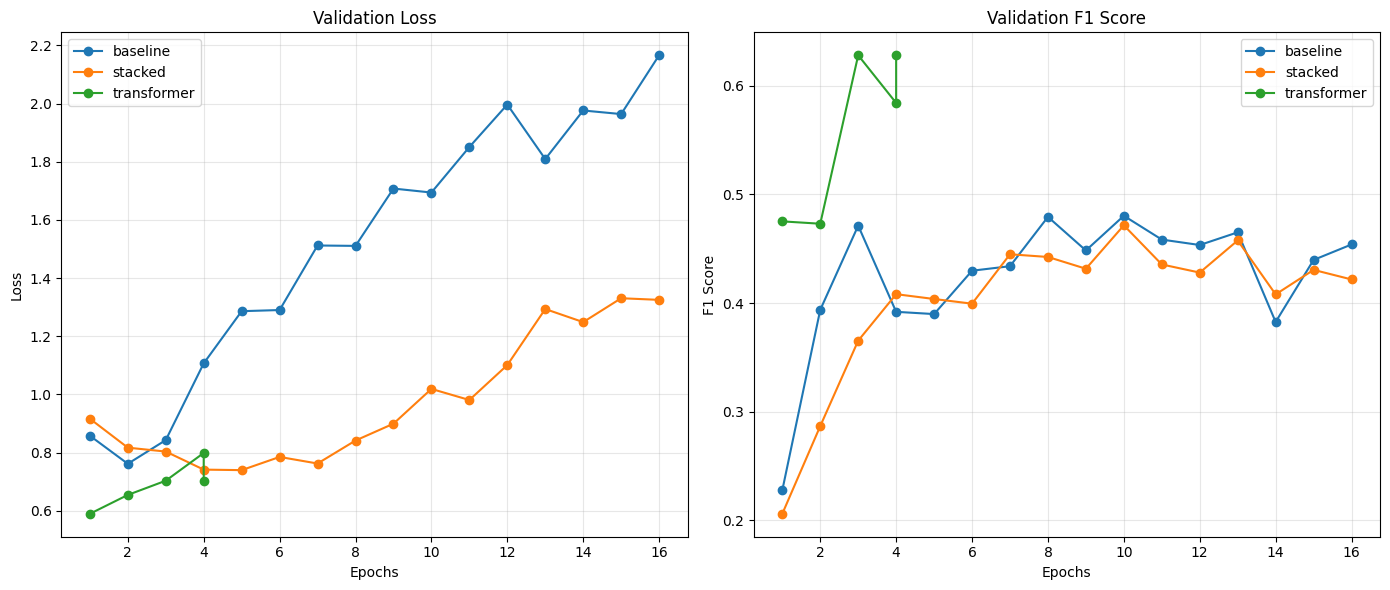

In [ ]:
def plot_learning_curves(m1_history, m2_history, transformer_history, download=False):
    # Extract Data for M1
    m1_val_f1 = m1_history.history['val_f1']
    m1_val_loss = m1_history.history['val_loss']
    m1_epochs = range(1, len(m1_val_loss) + 1)

    # Extract Data for M2
    m2_val_f1 = m2_history.history['val_f1']
    m2_val_loss = m2_history.history['val_loss']
    m2_epochs = range(1, len(m2_val_loss) + 1)

    # Extract Data for Transformer
    # filter only entries that have validation metrics
    eval_logs = [x for x in transformer_history if 'eval_f1' in x]
    trans_epochs = [x['epoch'] for x in eval_logs]
    trans_val_f1 = [x['eval_f1'] for x in eval_logs]
    trans_val_loss = [x['eval_loss'] for x in eval_logs]

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(m1_epochs, m1_val_loss, label='baseline', marker='o')
    plt.plot(m2_epochs, m2_val_loss, label='stacked', marker='o')
    plt.plot(trans_epochs, trans_val_loss, label='transformer', marker='o')
    plt.title('Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(m1_epochs, m1_val_f1, label='baseline', marker='o')
    plt.plot(m2_epochs, m2_val_f1, label='stacked', marker='o')
    plt.plot(trans_epochs, trans_val_f1, label='transformer', marker='o')
    plt.title('Validation F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if download:
        plt.savefig("learning_curves.png")
        from google.colab import files
        files.download("learning_curves.png")

    plt.show()

plot_learning_curves(m1_history, m2_history, transformer_history, True)

We can observe a divergence between F1 and loss in the LSTM models. While, after epoch 8, F1 remain stable, Loss penalizes "confident" mistakes: this shows the models start overfitting, becoming "overconfident" in their errors. Even if the labeling remains mostly accurate, this "penalty of confidence" causes the loss to rise.

<br>

NOTE: During LSTMs developement we focused our hyperparameter search mainly on other hyperparameters, rather than the number of epochs (we only tested 16 and 32 epochs). Having implemented the learning curve visualization only after completing the rest of the code, we realized the potential overfitting when the long training necessary for hyperparameeter grid search was concluded, so we kept the results already found.


We have nevertheless learned an important lesson about the importance of learning curve analysis early on in the development.


# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis on the **test set**:

### Instructions

 - Review the results and identify common errors.

 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

In [ ]:
def run_error_analysis(model_or_trainer, test_dataset, id2label, tokenizer_or_mapping):

    n_classes = 4

    # First we detect the model type (transformer or LSTM)
    is_keras = hasattr(model_or_trainer, 'compile')
    is_hf_tokenizer = hasattr(tokenizer_or_mapping, 'decode')

    if is_keras:
        # LSTM Logic
        print("Model detected: Keras/LSTM")
        raw_output = model_or_trainer.predict(test_dataset, verbose=1)
        model_outputs = torch.tensor(raw_output)
        is_logits = False

        # Extract inputs and labels from TF dataset
        all_x = []
        all_y = []
        for batch_x, batch_y in test_dataset:
            all_x.append(batch_x.numpy())
            all_y.append(batch_y.numpy())

        all_x = np.concatenate(all_x, axis=0)
        labels = torch.tensor(np.concatenate(all_y, axis=0))

    else:
        # Transformer Logic
        print("Model detected: Hugging Face Transformer")
        raw_pred_output = model_or_trainer.predict(test_dataset)
        model_outputs = torch.tensor(raw_pred_output.predictions)
        is_logits = True
        labels = torch.tensor(raw_pred_output.label_ids)

        # The Trainer sets the dataset format to 'torch' (tensors)
        # If tweets have different lengths, accessing 'input_ids' directly will crash
        # We must reset format to None (Python lists) to safely retrieve jagged arrays
        test_dataset.set_format(type=None, columns=list(test_dataset.features.keys()))

        all_x = test_dataset['input_ids']

    # Compute Losses
    if is_logits:
        logits = model_outputs
        probs = torch.nn.functional.softmax(logits, dim=-1)
        loss_fct = CrossEntropyLoss(reduction='none')
        losses = loss_fct(logits, labels.long())
    else:
        probs = model_outputs
        eps = 1e-7
        probs_clipped = torch.clamp(probs, min=eps, max=1.0 - eps)
        log_probs = torch.log(probs_clipped)
        loss_fct = NLLLoss(reduction='none')
        losses = loss_fct(log_probs, labels.long())

    # Dataframe Construction & Decoding
    preds = torch.argmax(probs, dim=-1)

    decoded_texts = []
    # Loop safely through inputs
    for ids in all_x:
        if is_hf_tokenizer:
            # Transformer Decoding
            decoded_texts.append(tokenizer_or_mapping.decode(ids, skip_special_tokens=True))
        else:
            # LSTM/Manual Decoding
            words = []
            for i in ids:
                idx = int(i)
                if idx != 0:
                    if 0 <= idx < len(tokenizer_or_mapping):
                        words.append(str(tokenizer_or_mapping[idx]))
                    else:
                        words.append("[UNK]")
            decoded_texts.append(" ".join(words))

    df_analysis = pd.DataFrame({
        'text': decoded_texts,
        'true_label_id': labels.numpy(),
        'pred_label_id': preds.numpy(),
        'loss': losses.numpy(),
        'confidence': torch.max(probs, dim=-1).values.numpy()
    })

    df_analysis['true_label'] = df_analysis['true_label_id'].map(id2label)
    df_analysis['pred_label'] = df_analysis['pred_label_id'].map(id2label)

    # Top 5 Errors
    wrong_preds = df_analysis[df_analysis['true_label_id'] != df_analysis['pred_label_id']]
    top_errors = wrong_preds.sort_values(by='loss', ascending=False).head(10)

    print(f"\nTotal Errors: {len(wrong_preds)} out of {len(df_analysis)} samples")
    print(f"Accuracy: {1 - (len(wrong_preds)/len(df_analysis)):.4f}")
    print("\n" + "="*50)
    print("TOP 5 WORST ERRORS (Highest Loss)")
    print("="*50)

    display_cols = ['text', 'true_label', 'pred_label', 'confidence', 'loss']
    if not top_errors.empty:
        error_view = top_errors.head(5)[display_cols].copy()
        error_view.columns = ['Tweet Text', 'True', 'Predicted', 'Conf', 'Loss']

        # Style the dataframe
        styled_errors = error_view.style.background_gradient(subset=['Conf'], cmap='Greens', vmin=0.5, vmax=1.0) \
                                        .format({'Conf': "{:.4f}", 'Loss': "{:.4f}"}) \
                                        .set_properties(**{'text-align': 'left'})

        # Display with context to show full text
        with pd.option_context('display.max_colwidth', None):
            display(styled_errors)
    else:
        print("No errors found!")

    # Plots
    # 1. Confusion Matrix
    cm = confusion_matrix(labels.numpy(), preds.numpy())
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=id2label.values(), yticklabels=id2label.values())
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # 2. Precision Recall Curves
    y_test_bin = label_binarize(labels.numpy(), classes=list(id2label.keys()))
    y_score = probs.numpy()

    plt.figure(figsize=(8, 6))
    for i in range(len(id2label)):
        if i < y_test_bin.shape[1]:
            precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
            plt.plot(recall, precision, lw=2, label=f'{id2label[i]}')

    plt.title("Precision-Recall Curve (One vs rest)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # 3. Per Class Metrics Bar Chart
    cls_precision, cls_recall, cls_f1, _ = precision_recall_fscore_support(
        labels.numpy(), preds.numpy(), average=None, labels=list(id2label.keys()), zero_division=0
    )

    x_idx = np.arange(len(id2label))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x_idx - width, cls_precision, width, label='Precision', alpha=0.8)
    rects2 = ax.bar(x_idx, cls_recall, width, label='Recall', alpha=0.8)
    rects3 = ax.bar(x_idx + width, cls_f1, width, label='F1-Score', alpha=0.8)

    ax.set_xlabel('Classes')
    ax.set_ylabel('Scores')
    ax.set_title('Per-Class Performance Metrics')
    ax.set_xticks(x_idx)
    ax.set_xticklabels([id2label[i] for i in x_idx])
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3)
    ax.set_ylim(0, 1.1)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    plt.show()

    # 4. ROC Curves
    plt.figure(figsize=(8, 6))

    # Compute ROC curve and ROC area for each class
    for i in range(n_classes):
        if i < y_test_bin.shape[1]:
            # Calculate ROC
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)

            # Plot
            plt.plot(fpr, tpr, lw=2, label=f'{id2label[i]} (AUC = {roc_auc:.2f})')

    # Plot diagonal line (random guess)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) - One vs Rest')
    plt.legend(loc="lower right")
    plt.show()

    # Classification Report
    print("\n" + "="*50)
    print("CLASSIFICATION REPORT")
    print("="*50)

    report_dict = classification_report(
        labels.numpy(),
        preds.numpy(),
        target_names=list(id2label.values()),
        output_dict=True,
        zero_division=0
    )

    accuracy_score = report_dict.pop("accuracy")
    print(f"Overall Accuracy: {accuracy_score:.4f} ({accuracy_score*100:.2f}%)")
    print("-" * 50)
    report_df = pd.DataFrame(report_dict).transpose()
    styled_report = report_df.style.background_gradient(subset=['f1-score'], cmap='Greens', vmin=0.0, vmax=1.0).format("{:.4f}")

    display(styled_report)
    return df_analysis, top_errors

**Baseline LSTM Error Analysis:**

Created vocabulary of size: 401822
Padding Token has index  0
Out of Vocabulary token has index  43001
Max length of tweets: 62
Model detected: Keras/LSTM
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step

Total Errors: 108 out of 280 samples
Accuracy: 0.6143

TOP 5 WORST ERRORS (Highest Loss)


,Tweet Text,True,Predicted,Conf,Loss
13,the violent [UNK] of a farright movement that see principally a vessel for breed a new white generation express itself in a fixation on a return to traditional gender [UNK] every minute to read take num min out of your sun,REPORTED,-,1.0000,16.1181
95,female chara be [UNK] isnt always bad n i know digimon have always kinda have an [UNK] issue most medium do tbh but it seem to be nearly the only way the game be interested in present woman and it kinda suck esp since yea the game be good,REPORTED,-,0.9998,16.1181
115,freud claim girl have a [UNK] the clitoris have phallic significance phallocentrism reduces even female genitalia to the phallus the other part of the vagina the clit and more constitute the plurality of female sexuality the clit coexist with [UNK] body part,JUDGEMENTAL,-,0.9999,16.1181
105,galaxy brain concept girl who transition so she can wear menswear in a stylish [UNK] sort of way that patriarchy doesnt let men do,JUDGEMENTAL,-,1.0000,16.1181
76,can you confront your misogyny misandry be hardly a problem in the world by comparison and if it exist it a reaction to abuse,JUDGEMENTAL,-,1.0000,16.1181


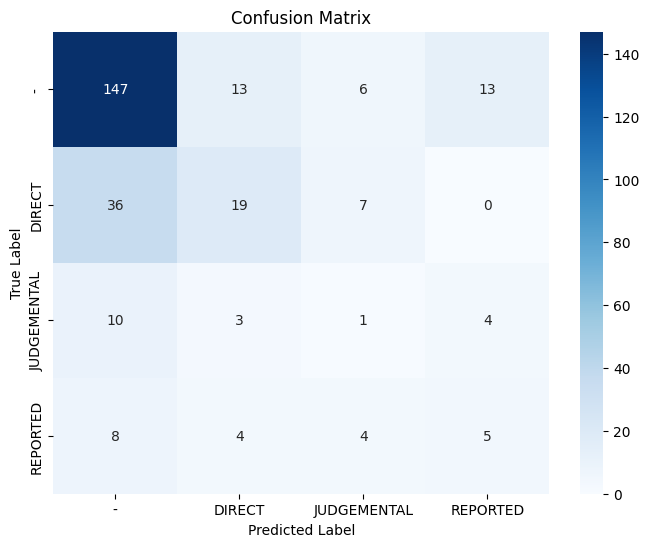

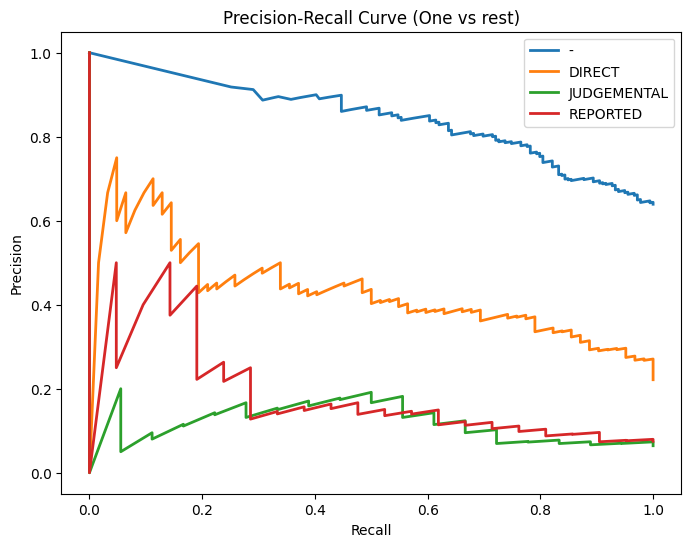

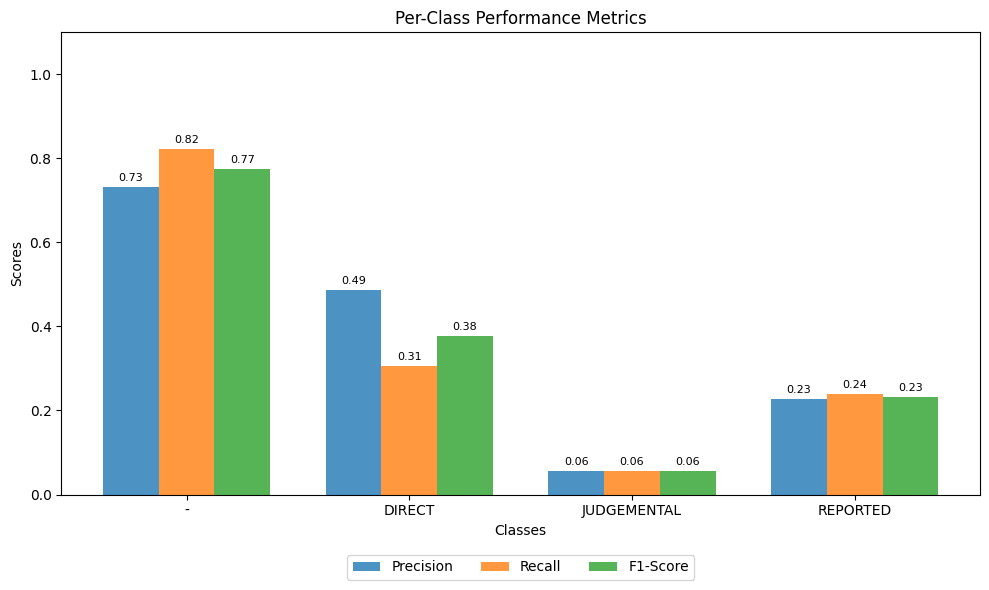

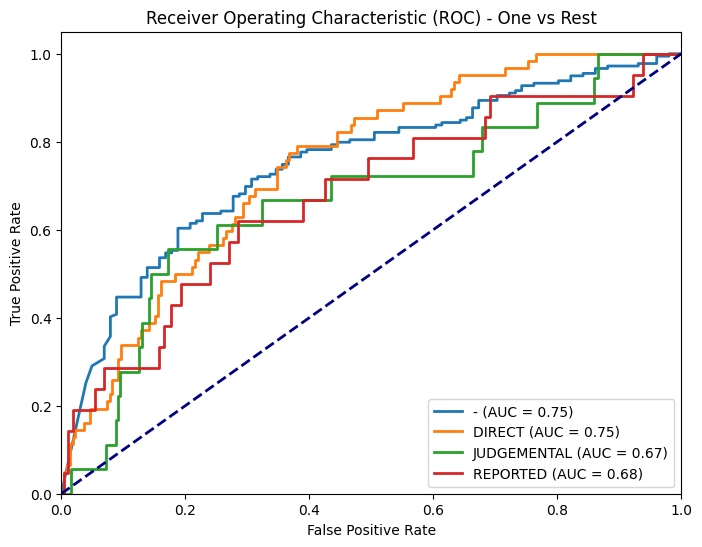


CLASSIFICATION REPORT
Overall Accuracy: 0.6143 (61.43%)
--------------------------------------------------


,precision,recall,f1-score,support
-,0.7313,0.8212,0.7737,179.0000
DIRECT,0.4872,0.3065,0.3762,62.0000
JUDGEMENTAL,0.0556,0.0556,0.0556,18.0000
REPORTED,0.2273,0.2381,0.2326,21.0000
macro avg,0.3753,0.3553,0.3595,280.0000
weighted avg,0.5960,0.6143,0.5989,280.0000


In [ ]:
train_df = train_df_raw.copy()
validation_df = validation_df_raw.copy()
test_df = test_df_raw.copy()
train_df = clean_tweet_data(train_df)
validation_df = clean_tweet_data(validation_df)
test_df = clean_tweet_data(test_df)

_, _, test_df_processed, _, _ , index_to_word = get_dataset_with_embeddings(
    train_df,
    validation_df,
    test_df,
    m1_hyperparams['embedding_dimension']
)
test_dataset_m1 = create_batches(test_df_processed, batch_size= m1_hyperparams['batch_size'], shuffle=False)


df_analysis, top_errors = run_error_analysis(m1_best_model, test_dataset_m1, ID2LABEL, index_to_word)


**Stacked LSTM Error Analysis:**

Created vocabulary of size: 401822
Padding Token has index  0
Out of Vocabulary token has index  43001
Max length of tweets: 62
Model detected: Keras/LSTM
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 484ms/step

Total Errors: 87 out of 280 samples
Accuracy: 0.6893

TOP 5 WORST ERRORS (Highest Loss)


,Tweet Text,True,Predicted,Conf,Loss
13,the violent [UNK] of a farright movement that see principally a vessel for breed a new white generation express itself in a fixation on a return to traditional gender [UNK] every minute to read take num min out of your sun,REPORTED,-,1.0000,12.3544
66,go weak rn play the guitar manspreading i be on my knee,DIRECT,-,1.0000,12.1567
64,mansplaining the concept of a pee drawer to my partner who want me,DIRECT,-,1.0000,11.5052
52,call to clean up parliament laddish culture after mp porn shame via,REPORTED,-,0.9999,11.4091
151,i dont care what gender race [UNK] orientation a person be as long a they be qualify for that position that be say be she qualify base on [UNK] or be she choose solely because she be black and gay to please [UNK] just say,DIRECT,-,0.9998,11.1717


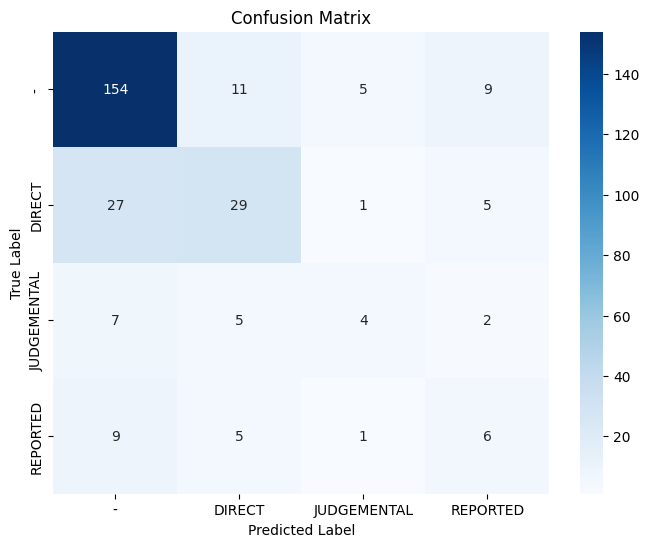

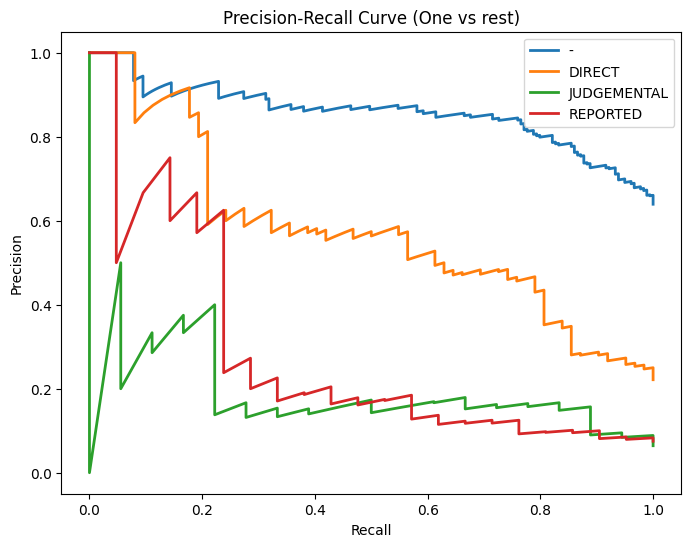

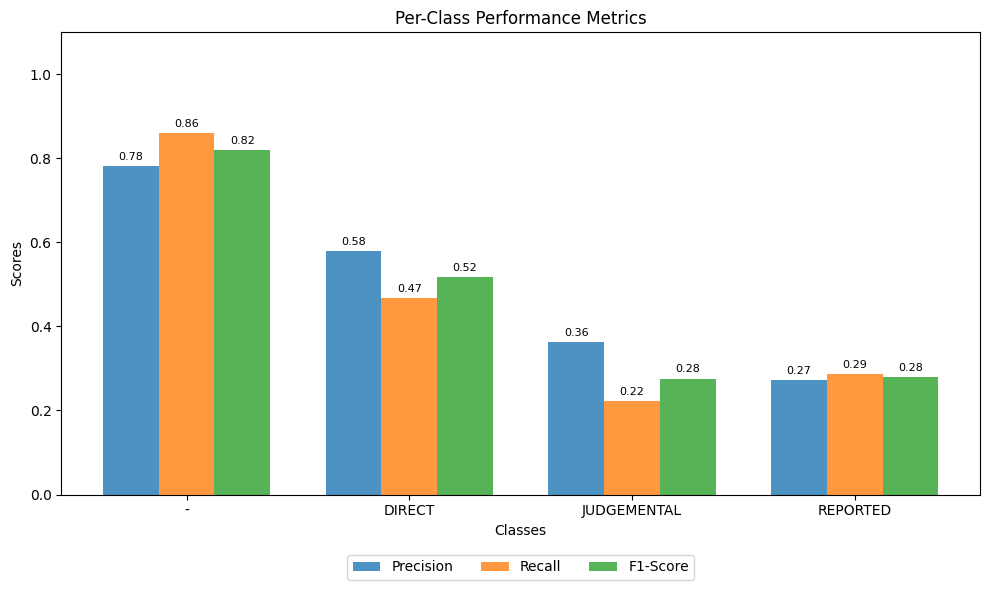

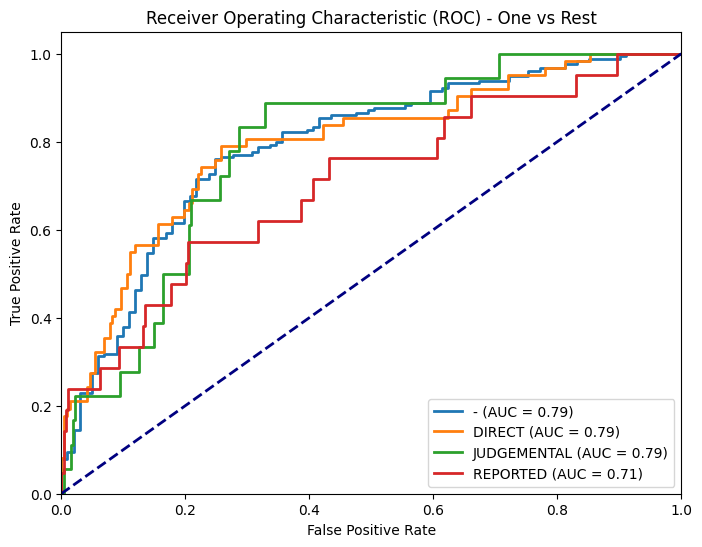


CLASSIFICATION REPORT
Overall Accuracy: 0.6893 (68.93%)
--------------------------------------------------


,precision,recall,f1-score,support
-,0.7817,0.8603,0.8191,179.0000
DIRECT,0.5800,0.4677,0.5179,62.0000
JUDGEMENTAL,0.3636,0.2222,0.2759,18.0000
REPORTED,0.2727,0.2857,0.2791,21.0000
macro avg,0.4995,0.4590,0.4730,280.0000
weighted avg,0.6720,0.6893,0.6770,280.0000


In [ ]:
_, _, test_df_processed, _, _ , index_to_word = get_dataset_with_embeddings(
    train_df,
    validation_df,
    test_df,
    m2_hyperparams['embedding_dimension']
)
test_dataset_m2 = create_batches(test_df_processed, batch_size= m2_hyperparams['batch_size'], shuffle=False)


df_analysis, top_errors = run_error_analysis(m2_best_model, test_dataset_m2, ID2LABEL, index_to_word)


**Transformer Error Analysis:**


Loading best model from best_model_lr2e-05_bs8_seed2024 for Error Analysis...
Model detected: Hugging Face Transformer



Total Errors: 66 out of 280 samples
Accuracy: 0.7643

TOP 5 WORST ERRORS (Highest Loss)


,Tweet Text,True,Predicted,Conf,Loss
114,Fuck's sake is it possible to have a furry space that's not explicitly content-restricted and doesn't immediately become yet another showcase for size-queen phallocentrism?,JUDGEMENTAL,-,0.9967,7.2040
105,"Galaxy brain concept: girl who transitions so she can wear menswear in a stylish, lesbicious sort of way that patriarchy doesn’t let men do https://t.co/wYIotXcAMP",JUDGEMENTAL,-,0.9956,6.9729
113,"@Mistywoman1 Have I missed something, or has phallocentrism become the latest cult?",JUDGEMENTAL,-,0.9949,6.8236
245,"@itzbrennan I didn’t even know that was possible omg sorry you gotta go through that. Uterus cramps, butt cramps, and now heart cramps women can’t catch a break 🥲",REPORTED,-,0.9953,6.6512
66,Going weak rn... PLAYING THE GUITAR?!?!?! MANSPREADING!?!??!?! I AM ON MY KNEES https://t.co/yKABMDXGmg,DIRECT,-,0.9961,6.2641


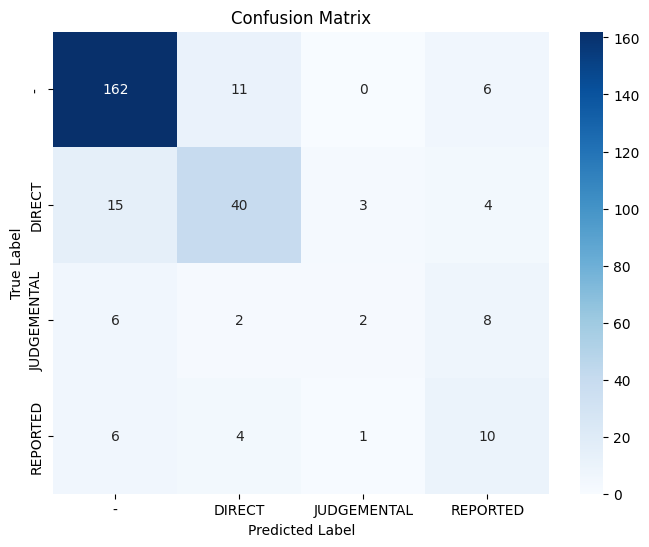

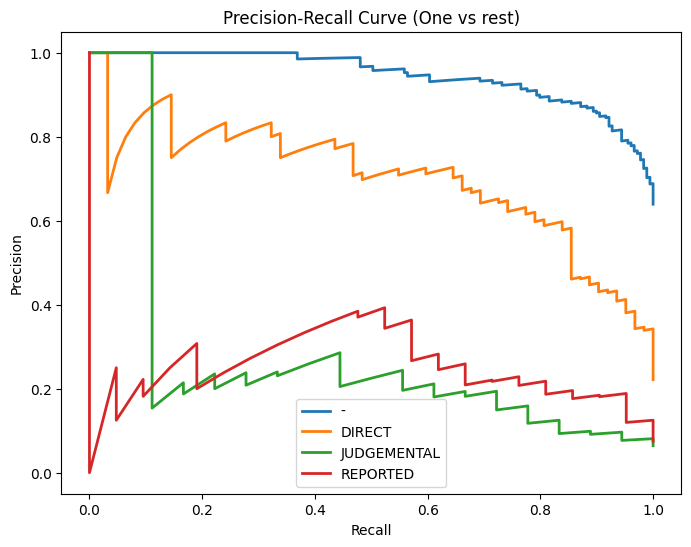

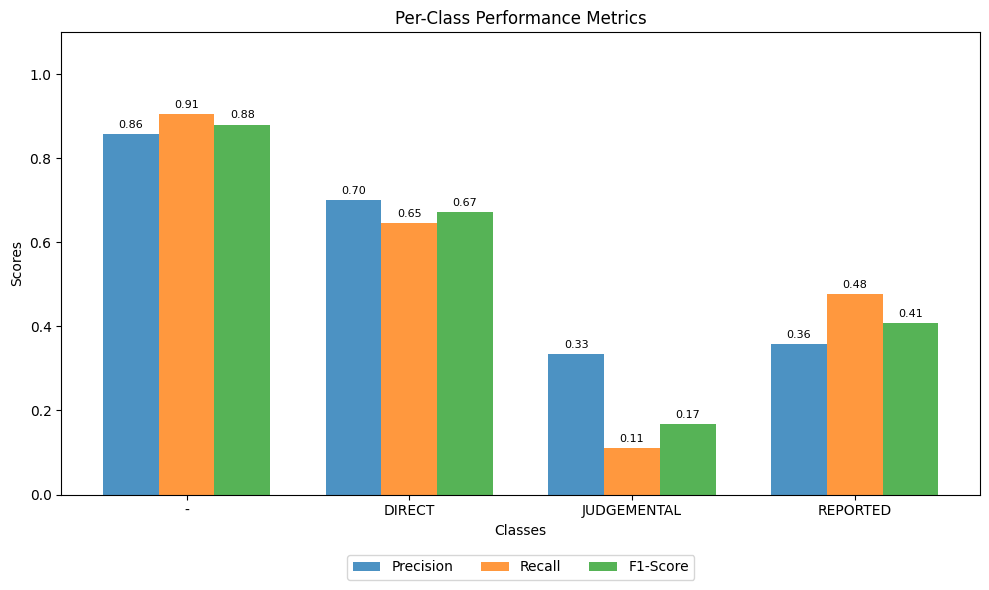

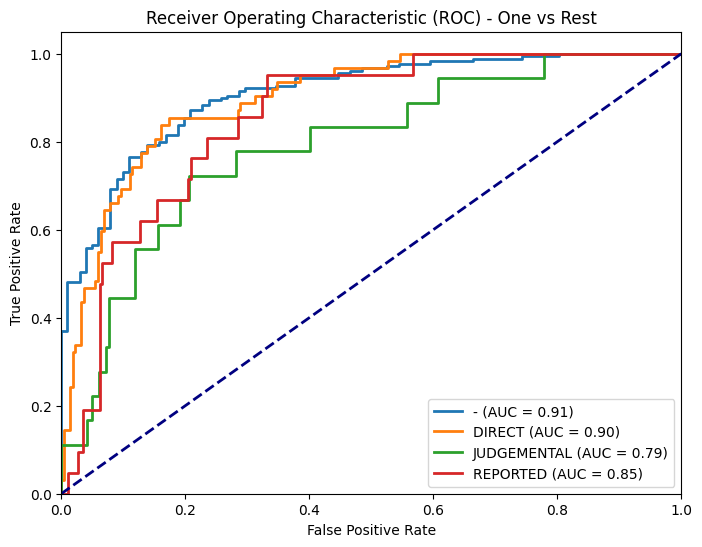


CLASSIFICATION REPORT
Overall Accuracy: 0.7643 (76.43%)
--------------------------------------------------


,precision,recall,f1-score,support
-,0.8571,0.9050,0.8804,179.0000
DIRECT,0.7018,0.6452,0.6723,62.0000
JUDGEMENTAL,0.3333,0.1111,0.1667,18.0000
REPORTED,0.3571,0.4762,0.4082,21.0000
macro avg,0.5623,0.5344,0.5319,280.0000
weighted avg,0.7516,0.7643,0.7530,280.0000


In [ ]:
# Load the best model and tokenizer
print(f"\nLoading best model from {global_best_model_path} for Error Analysis...")
best_model = AutoModelForSequenceClassification.from_pretrained(global_best_model_path)
best_tokenizer = AutoTokenizer.from_pretrained(global_best_model_path)

# Create Trainer for inference
analysis_trainer = Trainer(
    model=best_model,
    args=TrainingArguments(output_dir="temp_analysis", report_to='none'),
    data_collator=data_collator,
    processing_class=best_tokenizer
)

# Run the analysis function
df_errors, top_errors = run_error_analysis(analysis_trainer, test_data, ID2LABEL, best_tokenizer)

# Error Analysis Report

## 1. Review of Results and Common Errors

### Overall Performance Progression
The experiments demonstrate a clear performance hierarchy correlated with the models complexity (the results are relative to the test set).
* **Baseline LSTM:** Struggled significantly, achieving only **61% accuracy** and a Macro-F1 of **0.36**.
* **Stacked LSTM:** Provided a major leap, improving accuracy to **69%** and Macro-F1 to **0.47**.
* **RoBERTa Transformer:** Yielded the best overall generalization, reaching **76% accuracy** and a Macro-F1 of **0.53**.

### Common Error Patterns
Across all architectures, the confusion matrices reveal a persistent bias toward the majority class (`-`), due to data imbalance.
* **Baseline Model Failure:** The baseline model effectively failed to learn the minority classes, with an F1 score of just **0.05** for `JUDGEMENTAL`. It defaulted to predicting "non-sexist" for almost all ambiguous inputs.
* **Transformer "Nuance" Errors:** While the Transformer eliminated the vocabulary errors seen in LSTMs, its top losses shifted toward subtle semantic failures. For example, it missed the implicit sexism in complex phrases like *"size-queen phallocentrism"* (Loss: 7.17), misclassifying them as non-sexist likely due to the absence of standard hate keywords.

## 2. Findings on Specific Issues


* **Safe opening effect:** Some of the the major errors involves misclassifying sexist tweets as non-sexist. This frequently occurs when a tweet has a specific structure: `[Neutral/Positive Disclaimer] + [Adversarial Conjunction (BUT/OR/THAT BEING SAYED)] + [Sexist claiming or reporting]`. Models often weigh the beginning of the sentence too heavily, and then classify the tweet based on the safe opening while ignoring the toxic conclusion.

    * **Examples:**
        > "i dont care what gender race [UNK] orientation a person be as long a they be qualify for that position THAT BE SAYED be she qualify base on [UNK] or be she choose solely because she be black and gay to please [UNK] just say"

        > "female chara be [UNK] isnt always bad n i know digimon have always kinda have an [UNK] issue most medium do tbh BUT it seem to be nearly the only way the game be interested in present woman and it kinda suck esp since yea the game be good"
    

* **Contextual Ambiguity**: Certain inputs, lack sufficient context for accurate classification, generating ambiguity that divides human annotators and results in narrow majority consensus labels.

    * **Example (original)** (only 3/6 votes for `DIRECT` sexism):
        > "Going weak rn... PLAYING THE GUITAR?!?!?! MANSPREADING!?!??!?! I AM ON MY KNEES"

* **Complex Register**: Academic or sociological register is also used in some of the misclassified. These kind of phrasing can often be mislabeled as non sexist due to the absence of standard slurs and the use of "high" vocabulary.

    * **Example (original):**
        > " «The violent antifeminism of a far-right movement that sees [woman emojy] principally as vessels for breeding a new white generation expresses itself in a fixation on a return to traditional gender roles» Worth every minute to read, take 5 min out of your [link]"


* **Out-of-Vocabulary (OOV) and Tokenization:** The impact of tokenization strategy was explicitly visible in the error logs.
  * **LSTM Models (Static Vocabulary):** Both LSTM models suffered from out-of-vocabulary issues. The top errors for the Baseline LSTM contained `[UNK]` tokens, destroying the semantic meaning of the sentence, and eliminating important keywords, for example: *"... choose solely because she be black and gay to please [UNK]"*, the out of vocabulary token in this case is "woke" which can give important insights over the underlying political statement. This explains the model's inability to capture context, as crucial adjectives were replaced by generic placeholders.
  * **Transformer (Sub-word Tokenization):** The RoBERTa model successfully preserved the full text (no `[UNK]` tokens in top errors), allowing it to process rare slurs or compound words. This directly contributed to the higher recall for the `DIRECT` class (0.65 vs 0.47 in Stacked LSTM).


### Architecture Capability
* **Stacked vs. Baseline:** Adding depth (Stacked LSTM) significantly helped in feature extraction for minority classes. The F1-score for `JUDGEMENTAL` jumped from **0.05 (Baseline)** to **0.27 (Stacked)**, proving that a single LSTM layer was insufficient to capture the complex dependencies of implicit sexism.
* **Transformer Trade-off:** Interestingly, while the Transformer excelled at `DIRECT` sexism (F1 0.67), it actually struggled more with the recall of `JUDGEMENTAL` cases (F1 0.17) compared to the Stacked LSTM (F1 0.27). This suggests that while RoBERTa is powerful, fine-tuning a general-purpose model on such a small, imbalanced class (`JUDGEMENTAL` support: 18) can lead to conservative predictions unless weighted loss is applied.


## 3. Precision-Recall Curve Findings

The Precision-Recall curves confirm that class imbalance is the primary bottleneck for all models.

* **Dominance of the Majority Class (-):** All models achieved high performance on the non-sexist class. The Transformer reached near-perfect precision/recall balance here (F1 0.88), indicating it has effectively learned the features of "safe" tweets.
* **Degradation in Explicit Sexism (DIRECT):** The Transformer showed a robust curve for `DIRECT` sexism, maintaining high precision even at higher recall levels compared to the LSTMs. This confirms that attention mechanisms are superior at weighing explicit hate keywords within a sentence.
* **Keywords in Explicit Sexism (DIRECT):** Interestingly, even for the baseline LSTM model, it's possible to lower a bit the classification threshold while maintaining high levels of precision for DIRECT sexism predictions ( if compared with the ones in the 2 minority classes). This suggests that there are some "easy to classify" examples of direct sexism in the dataset. It's possible that this is due to the presence of explicit words or insults.
* **Critical Failure in Minority Classes:** The curves for `JUDGEMENTAL` and `REPORTED` remain problematic. The `JUDGEMENTAL` curve exhibits a "cliff" pattern in the Transformer results, plummeting to low precision immediately. This confirms that the model lacks a generalized understanding of "judgemental" language, relying essentially on a few specific patterns before guessing randomly.


## 4. ROC Curve Findings


We used ROC curves to observe how good the models are at separating the classes independently of class imbalance (which is havely visible in precision-recall curves).

* **Confirmation of previous findings:**  The **Transformer** exhibits the strongest separability, with AUCs of **0.90+** for both the majority class and `DIRECT` sexism. This confirms that the Transformer’s superior performance isn't just due to better thresholding, but a fundamentally better representation of the text in latent space. Across all three models, the `REPORTED` and `JUDGEMENTAL` classes consistently show the lowest AUCs.
* **The Capability of STACKED LSTM:** Interestingly, the ROC curves reveal that the **Stacked LSTM** is more capable than the PR curves suggest. While its F1-scores were low, an AUC of **0.79** for the `JUDGEMENTAL` class (matching the Transformer's AUC for that same class) indicates that the LSTM *can* actually distinguish this class from others. Its poor PR performance was likely a "calibration" issue—the model was unable to find a threshold that balanced precision and recall, even though it was ranking the samples relatively correctly.


## 4. Suggested Solutions

To address the identified errors, we propose the following improvements:

1. **Focal Loss:** We trained the stacked LSTM model using class weighting, but this gave no performance improvements. This suggests that the core issue is not just class imbalance bias, but rather poor class separability in the latent space: it is a problem of representation quality. The model simply struggles to distinguish between the semantic nuances of the classes.
To address this, Focal Loss could be effective. Unlike class weights, which scale all examples equally, Focal Loss down-weights "easy" inputs (like the majority class). This forces the model to focus specifically on "hard" examples, potentially sharpening the decision boundaries.

2.  **Back-Translation Augmentation:** To address the low support for `JUDGEMENTAL` (only 18 samples in test) and `REPORTED`, we can use Back-Translation (English -> French -> English). This would generate syntactically diverse training samples, helping the Transformer generalize better without relying on exact keyword matching.
3.  **Label Smoothing:** Given the high loss values in "Top Errors" (e.g., losses > 12.0), the models are often "confidently wrong." Label smoothing (e.g., 0.1) would penalize over-confidence, encouraging the model to learn more robust decision boundaries for ambiguous classes like `REPORTED` vs `JUDGEMENTAL`.
4. **Hierarchical Classification:** First, separate sexist and non sexist tweet, then classify the type of sexism. In this way a model could learn only the distinctions between the different types of sexism, improving performance.

5. **Optimize thresholding:** After obtaining as output the probability distribution on the classes, just picking the the highest probability might not be the best way to maximize F1 score, lower thresholds might be used for minority classes.